<a href="https://colab.research.google.com/github/Sirrat21/Data-Science-Analytics_Internship_Tasks/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('/content/Loan_default.csv')

In [4]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

# Handle Missing Values

In [6]:
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [7]:
df.drop_duplicates(inplace=True)

# **EDA**

### Loan Amount Distribution

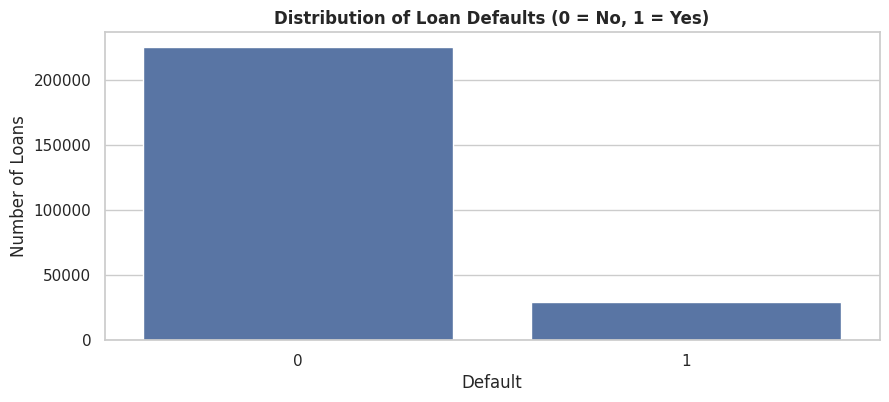

In [16]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='Default')
plt.title('Distribution of Loan Defaults (0 = No, 1 = Yes)', weight='bold')
plt.ylabel('Number of Loans')
plt.show()

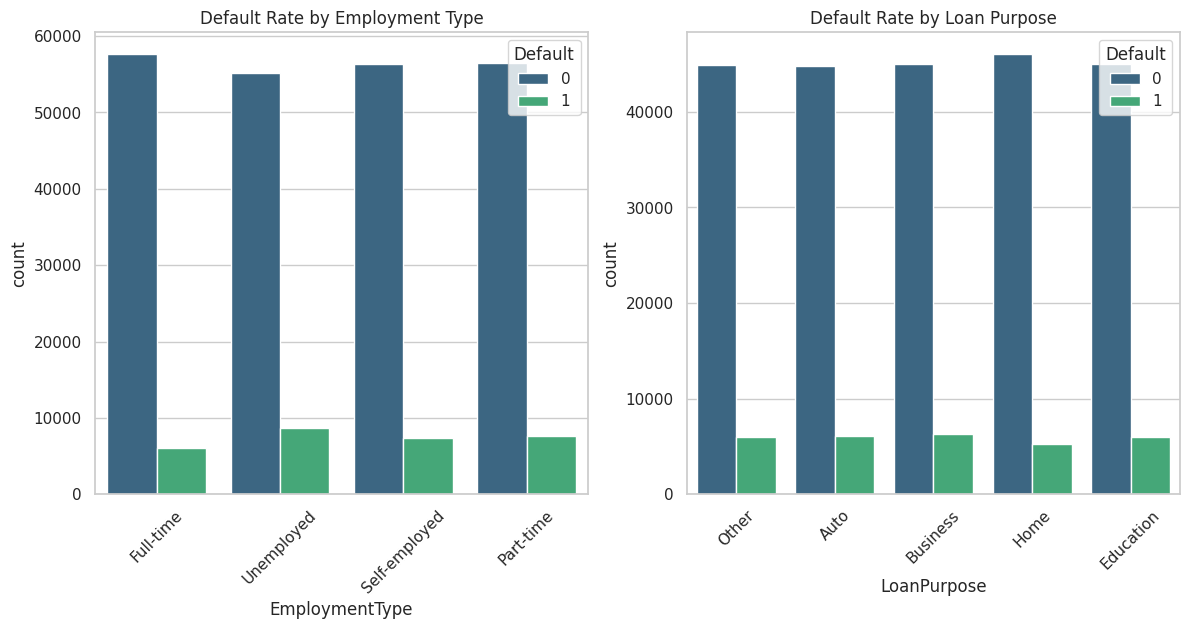

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(ax=axes[0], data=df, x='EmploymentType', hue='Default', palette='viridis')
axes[0].set_title('Default Rate by Employment Type')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(ax=axes[1], data=df, x='LoanPurpose', hue='Default', palette='viridis')
axes[1].set_title('Default Rate by Loan Purpose')
axes[1].tick_params(axis='x', rotation=45)

# **Split Data**

In [27]:
from sklearn.model_selection import train_test_split

In [29]:
X = df.drop('Default', axis=1)
y = df['Default']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
numeric_features = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed','NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

categorical_features = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

## *Pipelines building*

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
from sklearn.metrics import confusion_matrix
warnings.filterwarnings('ignore')

In [42]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [43]:
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=3))
])

# **Train Model**

### Logistic Regression

In [44]:
log_reg_pipeline.fit(X_train, y_train)
print("--- Logistic Regression ---")
log_preds = log_reg_pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, log_preds):.2f}")

--- Logistic Regression ---
Accuracy: 0.89


### Predictions

In [47]:
y_pred = log_reg_pipeline.predict(X_test)

# **Model Evaluation**

## **Accuracy**

In [49]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.885823379674956


## **Confusion Matrix**

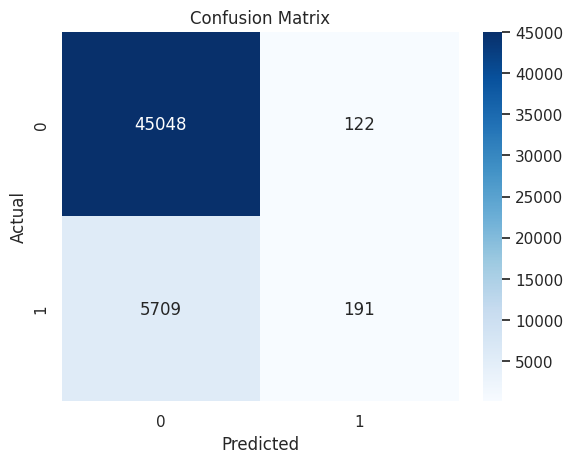

In [51]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **Conclusion**

1.  Missing data was successfully handled using median (numerical) and mode
(categorical) methods.

2. Key features like loan amount, income, and education were explored through visualizations to understand patterns.

3. Categorical variables were converted into numerical form using one-hot encoding.

4. A classification model (Logistic Regression / Decision Tree) was trained to predict loan default.

5. The model was evaluated using accuracy score, showing overall prediction performance.

6. Confusion matrix provided deeper insight into correct and incorrect predictions.

7. The model can help financial institutions identify high-risk applicants before approving loans.
8. some prediction errors still exist, indicating room for improvement.

9. Model performance can be improved further using feature engineering, hyperparameter tuning, or advanced algorithms.